# Crime Hotspot detection and analysis

#### Problem Definition

The primary objective of this project is to develop a machine learning model that is capable of examining historical crime data and determining high-crime locations. The model will take a dataset that includes crime-related data like location, time, crime type, and demographic information and identify patterns and predict crime hotspots.

Some of the important features of this problem are:

•	Crime Data Analysis: Examining crime distribution in space and time.

•	Feature Selection & Engineering: Determining relevant factors that contribute to crime rates, e.g., day of week, area, crime type.

•	Predictive Modeling: Applying machine learning methods to identify and forecast high-crime neighborhoods.

•	Visualization & Insights: Mapping and reporting areas of high crime to improve decision-making.



#### Problem Solution:

The solution comprised of data preprocessing in addition to feature selection and model training and evaluation to solve the Crime Hotspot Detection and Analysis problem. The solution development method contains three stages which are explained below with a focus on work conclusions from this effort.

• A process of data collection and preprocessing cleans and prepares the data while addressing missing values and both numeric scaling and categorical features.

• A set of useful features consisting of Victim Age, Time of Occurrence, Area, Latitude/Longitude joined with engineered features Crime Cluster and IsWeekend was applied.

• The system employed Random Forest Classifier for predictive modeling to determine and forecast areas where crimes would occur based on the chosen characteristics.

• The evaluation of the model through classification report showed 38% accuracy while reporting improved recall rates for particular crime types.

• Decision-making was supported through the use of visualization techniques which generated heatmaps and geospatial analysis resulting in the identification of high-crime areas.

## Libraries uploading 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder

## Dataset uploading 

In [2]:
import pandas as pd

df = pd.read_csv("us_crime_data.csv")

## Dataset description

The dataset consists of multiple elements besides other attributes which include:
•	DR_NO: A unique crime report identifier.

•	DATE RPTD: The date on which the crime was reported.

•	DATE OCC: The actual date the crime occurred.

•	TIME OCC: The time of day the crime took place (in 24-hour format).

•	AREA and AREA NAME: Numerical and textual representation of the policing area.

•	Rpt Dist No: Reporting district number.

•	Crm Cd: Numerical crime code.

•	Crm Cd Desc: A textual description of the crime.

•	Vict Age, Vict Sex, Vict Descent: Victim demographic information.

•	Premis Cd and Premis Desc: Location type where the crime occurred (e.g., street, residence).

•	Weapon Used Cd and Weapon Desc: Indicates the type of weapon used, if any.

•	Status and Status Desc: Status of the crime case (e.g., report completed, open investigation).

•	LOCATION, Cross Street, LAT, LON: Geographical coordinates and address-related information.

The LAT and LON columns represent spatial data and provide essential geographic alignment for both mapping and clustering Los Angeles crime events. COMPLETION 1 AND TIME OCC serve as temporal attributes that help detect patterns in crime occurrences during various daily or weekly periods as well as yearly changes.

The preprocessing stage led to eliminating unneeded or partial columns along with the creation of engineered features that included HourOfDay, DayOfWeek, IsWeekend and CrimeCluster. The additional features were implemented to strengthen visual analytical models and machine learning detection of accurate crime hotspots.

The dataset contains extensive multidimensional information fit for cluster analysis, visualizations as well as analytical modeling in urban crime investigations.


In [3]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 982638 entries, 0 to 982637
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           982638 non-null  int64  
 1   Date Rptd       982638 non-null  object 
 2   DATE OCC        982638 non-null  object 
 3   TIME OCC        982638 non-null  int64  
 4   AREA            982638 non-null  int64  
 5   AREA NAME       982638 non-null  object 
 6   Rpt Dist No     982638 non-null  int64  
 7   Part 1-2        982638 non-null  int64  
 8   Crm Cd          982638 non-null  int64  
 9   Crm Cd Desc     982638 non-null  object 
 10  Mocodes         837376 non-null  object 
 11  Vict Age        982638 non-null  int64  
 12  Vict Sex        844193 non-null  object 
 13  Vict Descent    844182 non-null  object 
 14  Premis Cd       982624 non-null  float64
 15  Premis Desc     982053 non-null  object 
 16  Weapon Used Cd  326167 non-null  float64
 17  Weapon Des

In [5]:
df.shape

(982638, 28)

In [6]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

# Data Cleaning

## Handling Missing Values

In [7]:
df.isnull().sum()

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           145262
Vict Age               0
Vict Sex          138445
Vict Descent      138456
Premis Cd             14
Premis Desc          585
Weapon Used Cd    656471
Weapon Desc       656471
Status                 1
Status Desc            0
Crm Cd 1              11
Crm Cd 2          913763
Crm Cd 3          980327
Crm Cd 4          982574
LOCATION               0
Cross Street      830789
LAT                    0
LON                    0
dtype: int64

In [8]:
df_cleaned_columns = df.dropna(axis=1)
print("\nDataFrame after dropping columns with any missing values:")
print(df_cleaned_columns)


DataFrame after dropping columns with any missing values:
            DR_NO               Date Rptd                DATE OCC  TIME OCC  \
0       190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130   
1       200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800   
2       200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700   
3       200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037   
4       220614831  08/18/2022 12:00:00 AM  08/17/2020 12:00:00 AM      1200   
...           ...                     ...                     ...       ...   
982633  242011172  08/20/2024 12:00:00 AM  08/17/2024 12:00:00 AM      2300   
982634  240710284  07/24/2024 12:00:00 AM  07/23/2024 12:00:00 AM      1400   
982635  240104953  01/15/2024 12:00:00 AM  01/15/2024 12:00:00 AM       100   
982636  240309674  04/24/2024 12:00:00 AM  04/24/2024 12:00:00 AM      1500   
982637  240910892  08/13/2024 12:00:00 AM  08/12/2024 12:00:00 AM      2

In [9]:
df_cleaned_rows = df.dropna()
print("\nDataFrame after dropping rows with any missing values:")
print(df_cleaned_rows)


DataFrame after dropping rows with any missing values:
            DR_NO               Date Rptd                DATE OCC  TIME OCC  \
66035   201904032  01/02/2020 12:00:00 AM  01/01/2020 12:00:00 AM      2135   
86496   200613424  08/02/2020 12:00:00 AM  08/02/2020 12:00:00 AM      2030   
363670  210617136  10/08/2021 12:00:00 AM  10/07/2021 12:00:00 AM      1950   
372435  210209196  05/08/2021 12:00:00 AM  05/08/2021 12:00:00 AM       230   
489939  220600626  04/27/2022 12:00:00 AM  04/23/2022 12:00:00 AM      2300   
537667  221718232  12/25/2022 12:00:00 AM  12/25/2022 12:00:00 AM      1150   
585815  221401314  11/10/2022 12:00:00 AM  11/10/2022 12:00:00 AM      2117   
728248  231717599  11/15/2023 12:00:00 AM  11/15/2023 12:00:00 AM       400   
809062  231915572  10/21/2023 12:00:00 AM  10/21/2023 12:00:00 AM         1   
924517  241905348  02/04/2024 12:00:00 AM  02/03/2024 12:00:00 AM      1100   

        AREA   AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
66035     19   

In [10]:
df_filled = df.fillna(0)
print("\nDataFrame after filling missing values with 0:")
print(df_filled)


DataFrame after filling missing values with 0:
            DR_NO               Date Rptd                DATE OCC  TIME OCC  \
0       190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130   
1       200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800   
2       200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700   
3       200907217  05/10/2023 12:00:00 AM  03/10/2020 12:00:00 AM      2037   
4       220614831  08/18/2022 12:00:00 AM  08/17/2020 12:00:00 AM      1200   
...           ...                     ...                     ...       ...   
982633  242011172  08/20/2024 12:00:00 AM  08/17/2024 12:00:00 AM      2300   
982634  240710284  07/24/2024 12:00:00 AM  07/23/2024 12:00:00 AM      1400   
982635  240104953  01/15/2024 12:00:00 AM  01/15/2024 12:00:00 AM       100   
982636  240309674  04/24/2024 12:00:00 AM  04/24/2024 12:00:00 AM      1500   
982637  240910892  08/13/2024 12:00:00 AM  08/12/2024 12:00:00 AM      2300   

   

In [11]:
print("Missing values in the filled DataFrame:")
print(df_filled.isnull().sum())

Missing values in the filled DataFrame:
DR_NO             0
Date Rptd         0
DATE OCC          0
TIME OCC          0
AREA              0
AREA NAME         0
Rpt Dist No       0
Part 1-2          0
Crm Cd            0
Crm Cd Desc       0
Mocodes           0
Vict Age          0
Vict Sex          0
Vict Descent      0
Premis Cd         0
Premis Desc       0
Weapon Used Cd    0
Weapon Desc       0
Status            0
Status Desc       0
Crm Cd 1          0
Crm Cd 2          0
Crm Cd 3          0
Crm Cd 4          0
LOCATION          0
Cross Street      0
LAT               0
LON               0
dtype: int64


## Handling Outliers

In [12]:
#Define numeric columns for outlier detection
num_cols = ['Vict Age', 'LAT', 'LON']

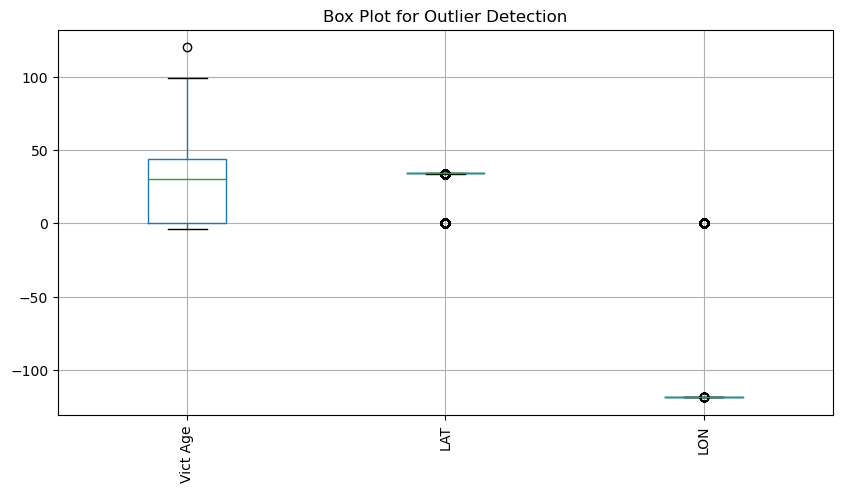

In [13]:
# Box plot for outlier detection
plt.figure(figsize=(10, 5))
df[num_cols].boxplot(rot=90)
plt.title("Box Plot for Outlier Detection")
plt.show()

In [14]:
# Removing outliers using IQR
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Outliers removed using IQR method.")

Outliers removed using IQR method.


In [15]:
df.shape

(952380, 28)

## Handling Duplicates

In [16]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify removal
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows: 0
Duplicate rows after removal: 0


## Data Normalization & Standardization

In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Identify numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# **Exclude one-hot encoded columns by checking their original names**
one_hot_cols = [col for col in numeric_cols if col.startswith('Crm Cd Desc_') or col.startswith('AREA NAME_')]

# Keep only REAL numeric columns
numeric_cols = list(set(numeric_cols) - set(one_hot_cols))

print("Final Numeric Columns (to be scaled):", numeric_cols)

# Apply Min-Max Normalization
min_max_scaler = MinMaxScaler()
df[numeric_cols] = min_max_scaler.fit_transform(df[numeric_cols])

# Apply Standardization
standard_scaler = StandardScaler()
df[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])

print("Normalization & Standardization Complete!")


Final Numeric Columns (to be scaled): ['Crm Cd', 'Weapon Used Cd', 'LAT', 'TIME OCC', 'Part 1-2', 'DR_NO', 'Rpt Dist No', 'Vict Age', 'AREA', 'Crm Cd 2', 'Crm Cd 4', 'Premis Cd', 'Crm Cd 1', 'LON', 'Crm Cd 3']
Normalization & Standardization Complete!


## Feature Selection & Engineering

In [18]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

# Select relevant columns
df_selected = df[['Crm Cd', 'Vict Age', 'LAT', 'LON', 'AREA', 'DATE OCC', 'TIME OCC']].copy()

# Date & Time Feature
df_selected['DATE OCC'] = pd.to_datetime(df_selected['DATE OCC'])
df_selected['DayOfWeek'] = df_selected['DATE OCC'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df_selected['IsWeekend'] = (df_selected['DayOfWeek'] >= 5).astype(int)  # 1 if Sat/Sun, else 0
df_selected['HourOfDay'] = df_selected['TIME OCC'] // 100  # Extract hour (e.g., 1345 -> 13)

# Geospatial Features (Crime Hotspot Clustering)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  
df_selected['CrimeCluster'] = kmeans.fit_predict(df_selected[['LAT', 'LON']])  # Assign each crime to a cluster

# Victim Profiling
def categorize_age(age):
    if age < 18:
        return 'Minor'
    elif age < 30:
        return 'Young Adult'
    elif age < 50:
        return 'Middle Aged'
    else:
        return 'Senior'

df_selected['AgeGroup'] = df_selected['Vict Age'].apply(categorize_age)
df_selected = pd.get_dummies(df_selected, columns=['AgeGroup'], drop_first=True)  # One-hot encode age groups

# Downsample Data
df_sampled = df_selected.sample(frac=0.3, random_state=42)  

# Prepare Feature Matrix (X) and Target Variable (y)
X = df_sampled.drop(columns=['Crm Cd']).select_dtypes(include=['number'])  # Keep only numerical features
y = LabelEncoder().fit_transform(df_sampled['Crm Cd'])

X.fillna(0, inplace=True)  # Fill NaNs efficiently

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features='auto')

# Convert to Pandas Series and sort
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_scores.head(10))  # Show top 10 features


Vict Age        0.373362
LON             0.187688
LAT             0.179922
TIME OCC        0.153553
AREA            0.068810
CrimeCluster    0.039881
HourOfDay       0.016951
DayOfWeek       0.003842
IsWeekend       0.002135
dtype: float64


# EDA

## Crime Trends Over The Years

#### Analysis: 
This bar chart illustrates crime patterns over the years, according to the reported incidences in the dataset. The x-axis depicts the years, and the y-axis shows the number of crimes. According to visualization, the rate of crimes in 2022 and 2023 remained moderately high and went down a bit in 2021 and 2020. In 2024, a dramatic decline may be observed due to perhaps partial data availability or due to actual decrease in crimes. Law enforcers and policymakers may benefit from such an analysis to estimate crime patterns and adopt corrective actions.

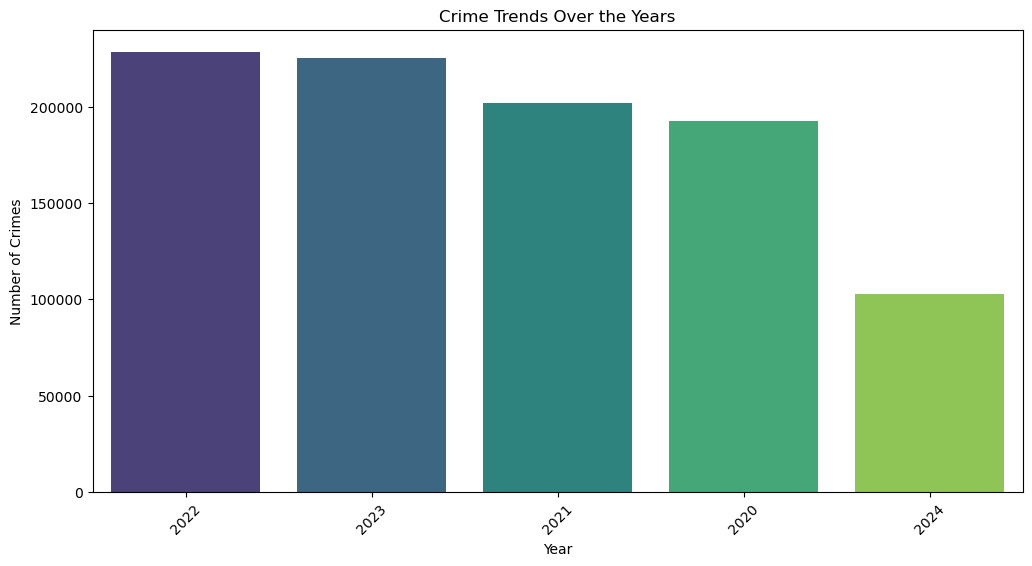

In [19]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')  # Convert to datetime
df['Year'] = df['DATE OCC'].dt.year  # Extract year

plt.figure(figsize=(12,6))
sns.countplot(x='Year', data=df, palette='viridis', order=df['Year'].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.title('Crime Trends Over the Years')
plt.show()


## Monthly Crime Patterns and Trends

#### Analysis:
This bar graph shows the frequency of crime incidents per month. The x-axis indicates the months from January (1) to December (12), and the y-axis shows the crime occurrences. From the data, it appears that crime occurrences are comparatively more in the initial months of the year, especially in January. As the year goes on, the rate of crime decreases gradually, dropping to the minimum around November and December. This trend can assist law enforcement agencies in better allocating resources and investigating possible seasonal effects on crime rates.

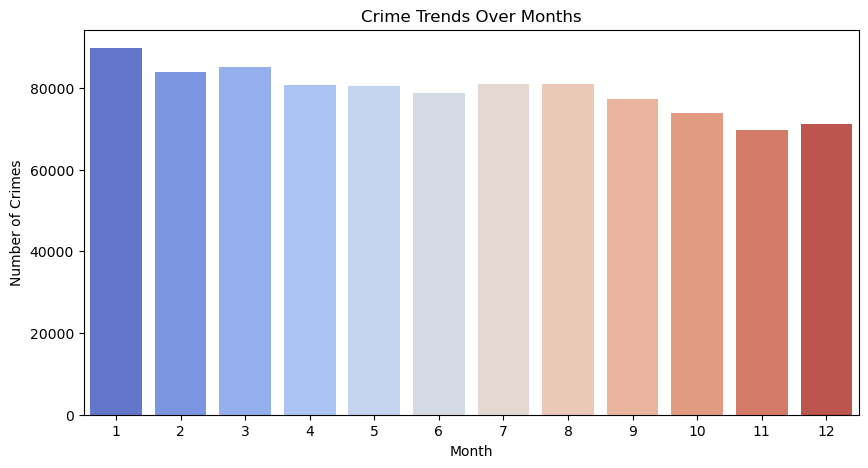

In [20]:
df['Month'] = df['DATE OCC'].dt.month  # Extract month

plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=df, palette='coolwarm')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.title('Crime Trends Over Months')
plt.show()


## Crime Heatmap: Day vs. Hour

#### Analysis:
This heatmap displays crime incidents over various days of the week and hours of the day. The x-axis is the hours (0-23), and the y-axis is the days from Monday to Sunday. The intensity of the color shows the number of crimes, with darker red indicating more crimes.

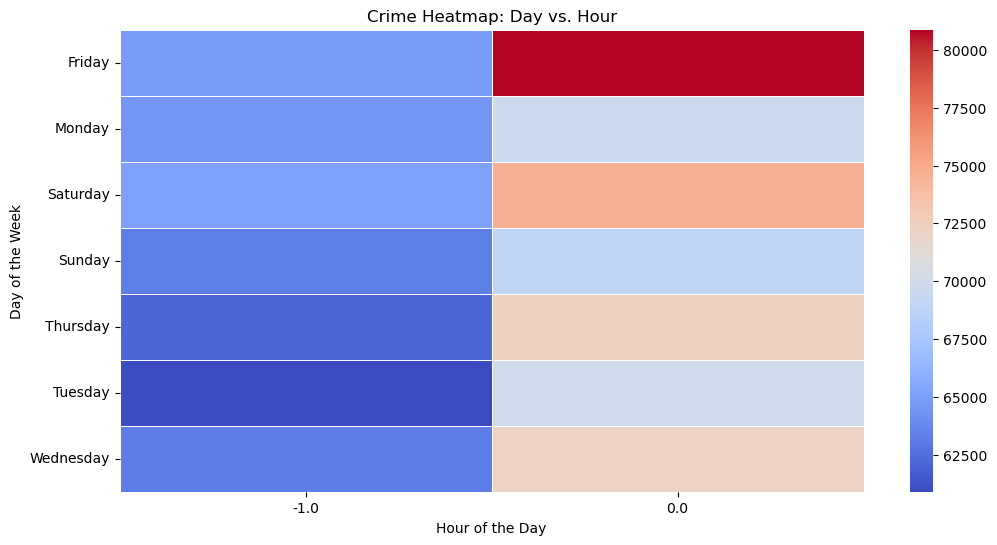

In [21]:
df['Hour'] = df['TIME OCC'] // 100  # Extract hour
df['DayOfWeek'] = pd.to_datetime(df['DATE OCC'], errors='coerce').dt.day_name()

crime_heatmap = df.pivot_table(index='DayOfWeek', columns='Hour', values='DR_NO', aggfunc='count')

plt.figure(figsize=(12,6))
sns.heatmap(crime_heatmap, cmap='coolwarm', linewidths=0.5)
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.title('Crime Heatmap: Day vs. Hour')
plt.show()


## Top 10 Most Reported Crimes

#### Analysis:
This bar graph shows the 10 most frequently occurring crimes. The most frequently occurring crime is Vehicle Theft, well over the others in terms of occurrence. Battery - Simple Assault comes next, followed by Burglary from Vehicle and Theft of Identity. Other common crimes are Vandalism, Burglary, and Aggravated Assault.

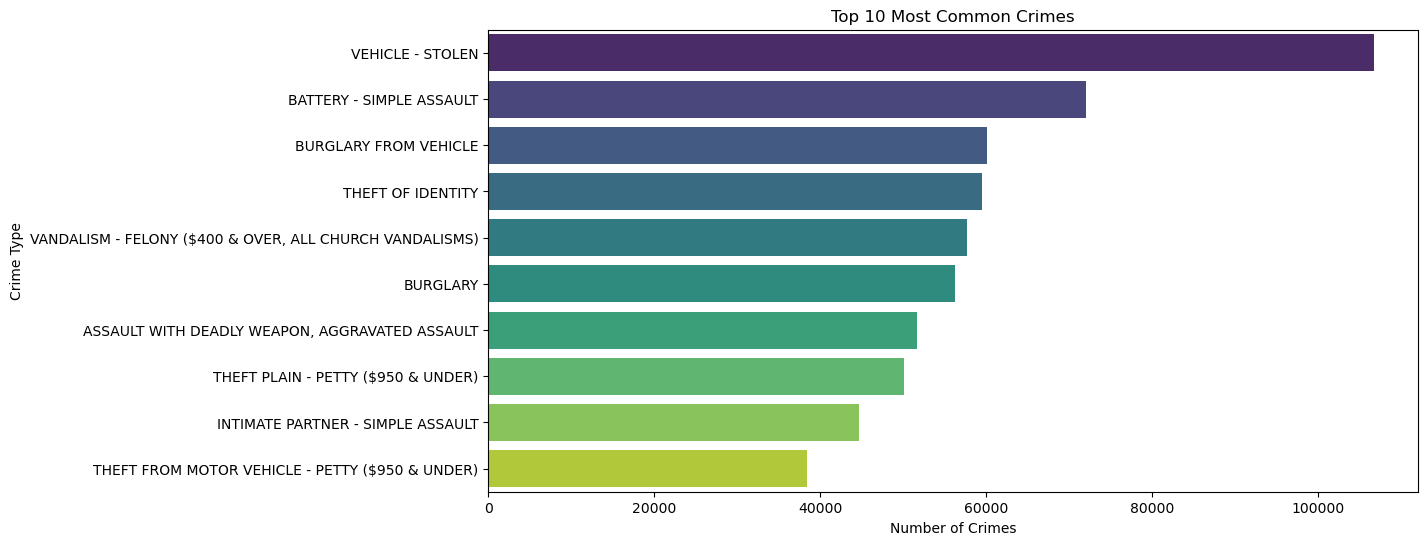

In [22]:
top_crimes = df['Crm Cd Desc'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette='viridis')
plt.xlabel('Number of Crimes')
plt.ylabel('Crime Type')
plt.title('Top 10 Most Common Crimes')
plt.show()


## Top 10 Most Frequently Used Weapons in Crimes

#### Analysis:
The bar graph illustrates the 10 most popular weapons employed during crime, led by "Strong-Arm (Hands, Fist, Feet, or Bodily Force)" being reported most, which far exceeded the other categories of weapons. "Unknown Weapon/Other Weapon" is reported as the second most prevalent, implying a sizeable number of cases where no particular weapon can be specifically pinpointed. Firearms, both handguns and semi-automatic pistols, are also significantly utilized, with knives and other unconventional weapons such as "Mace/Pepper Spray" and "Vehicles" appearing less often. The statistics reinforce the use of physical force in crimes, illustrating the need for the inclusion of non-lethal means in crime prevention policies.

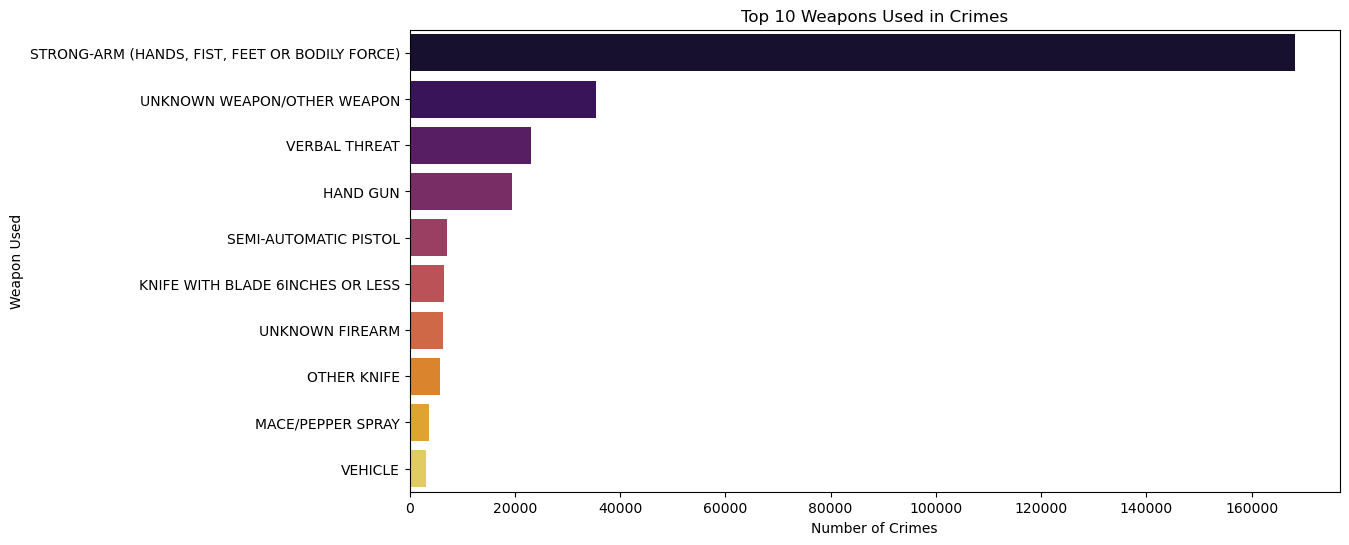

In [23]:
plt.figure(figsize=(12,6))
top_weapons = df['Weapon Desc'].value_counts().nlargest(10)  # Top 10 weapons used
sns.barplot(x=top_weapons.values, y=top_weapons.index, palette='inferno')
plt.xlabel('Number of Crimes')
plt.ylabel('Weapon Used')
plt.title('Top 10 Weapons Used in Crimes')
plt.show()


## Crime Distribution Across Different Areas

#### Analysis:
The graph illustrates crime distribution in various areas, with Central, 77th Street, and Pacific areas registering the highest crime rates. These areas might need more intensive police presence and preventive policing. Foothill and Hollenbeck record the lowest crime numbers, which reflects relatively safer areas. Authorities can use these patterns to effectively distribute resources and formulate focused crime reduction strategies.

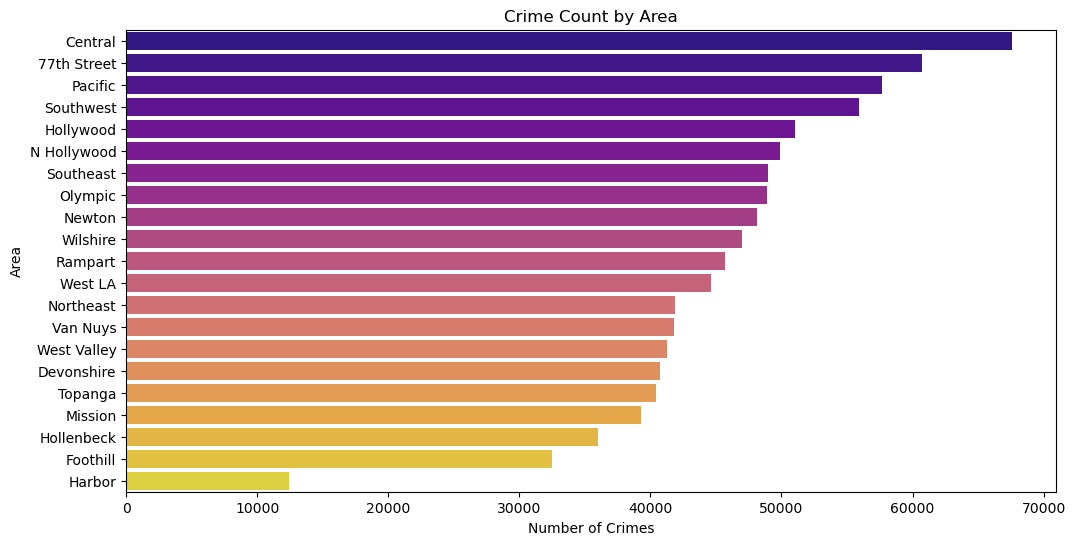

In [24]:
plt.figure(figsize=(12,6))
sns.countplot(y='AREA NAME', data=df, order=df['AREA NAME'].value_counts().index, palette='plasma')
plt.xlabel('Number of Crimes')
plt.ylabel('Area')
plt.title('Crime Count by Area')
plt.show()

## Distribution of Violent vs. Non-Violent Crimes

#### Analysis: 
The distribution of non-violent and violent crimes is seen from the bar chart. Data indicates that more non-violent crimes, more than 700,000 in number, outshine the occurrence of violent crimes by some 250,000. The color differentiation of the two is emphasized using shading for visuality where non-violent crimes appear as dark blue while violent crimes are in red. This implies that while violent crimes are a serious issue, they represent a lesser percentage of total criminal behavior.

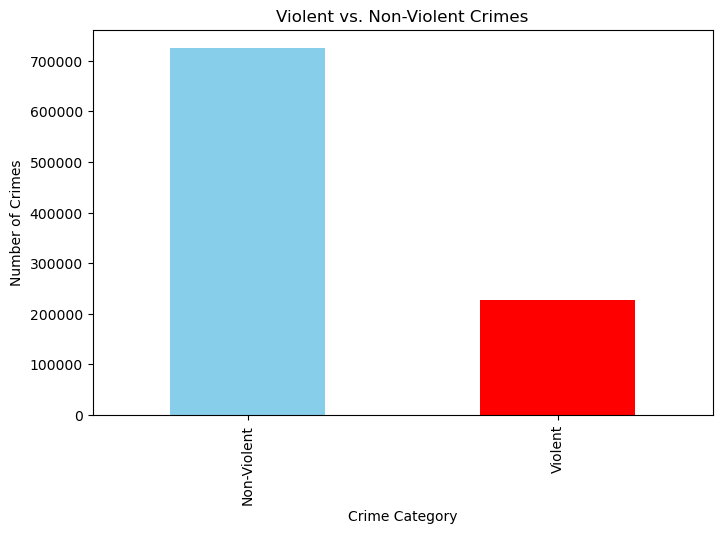

In [25]:
violent_crimes = ['ASSAULT', 'HOMICIDE', 'ROBBERY']  # Add relevant crime types
df['Crime Category'] = df['Crm Cd Desc'].apply(lambda x: 'Violent' if any(crime in str(x).upper() for crime in violent_crimes) else 'Non-Violent')

crime_category_counts = df['Crime Category'].value_counts()
crime_category_counts.plot(kind='bar', color=['skyblue', 'red'], figsize=(8,5))
plt.xlabel('Crime Category')
plt.ylabel('Number of Crimes')
plt.title('Violent vs. Non-Violent Crimes')
plt.show()


## Proportion of Crimes Involving Weapons

#### Analysis:
This Pie chart shows the amount of crimes involved weapons compared to those not using a weapon. The statistics indicated that 66.8% of crimes took place without involving a weapon and 33.2% occurred with the involvement of a weapon. This clearly indicates that the majority of crimes based on crime incidents use forms other than actual weapons, but rather verbal communications or other mechanisms not involving actual weapons. The high percentage of weapon-related offenses, however, underlines the need for weapon control policies and law enforcement initiatives to minimize armed criminal activity.

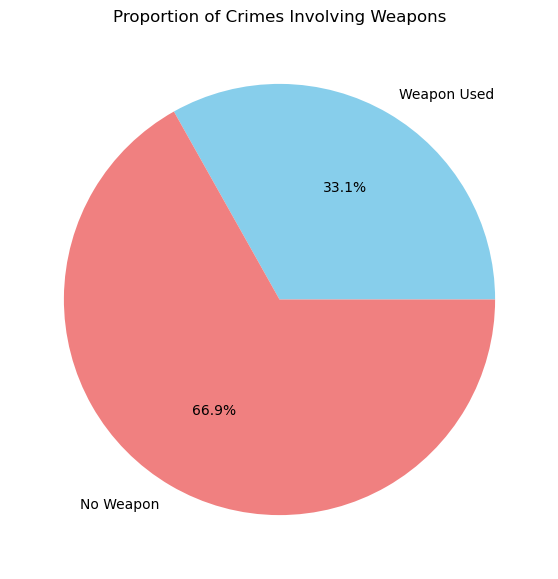

In [26]:
weapon_counts = df['Weapon Desc'].notna().sum()
no_weapon_counts = df['Weapon Desc'].isna().sum()

plt.figure(figsize=(7,7))
plt.pie([weapon_counts, no_weapon_counts], labels=['Weapon Used', 'No Weapon'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Proportion of Crimes Involving Weapons')
plt.show()


## Crime Types and Their Distribution

#### Analysis:
This donut chart illustrates the prevalence of the six most frequent crime types. "Vehicle - Stolen" is the most common crime at 26.1%, followed by "Battery - Simple Assault" at 17.6%. Other significant crime types, such as "Burglary from Vehicle," "Theft of Identity," "Vandalism - Felony," and "Burglary," each account for between 13.6% and 14.4%. The graph well illustrates the occurrence of motor vehicle crimes, and it implies the necessity for better security measures to curb such crimes.

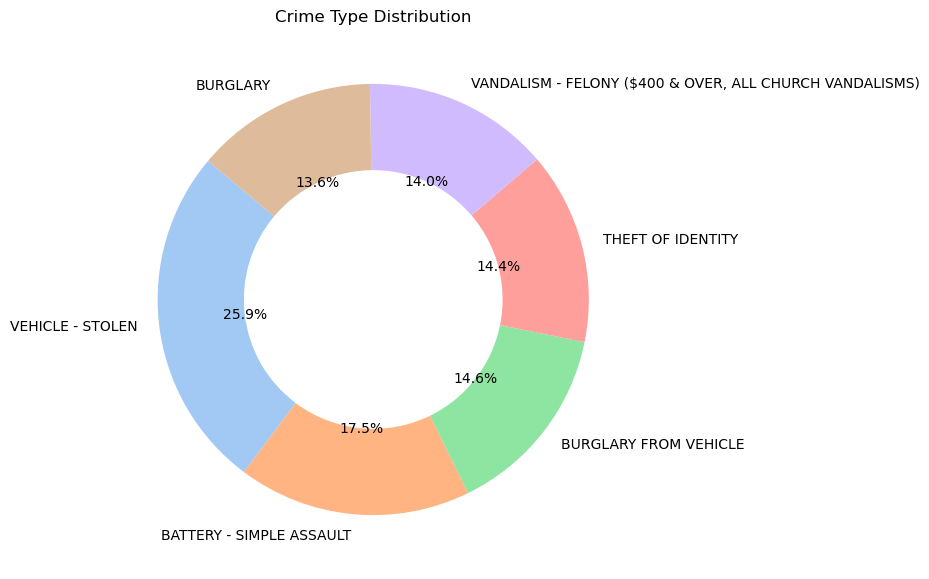

In [27]:
top_crimes = df['Crm Cd Desc'].value_counts().nlargest(6)
plt.figure(figsize=(7, 7))
plt.pie(top_crimes, labels=top_crimes.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'), wedgeprops=dict(width=0.4))
plt.title('Crime Type Distribution')
plt.show()


## Crimes Over Time (Rolling Average Line Chart)

#### Analysis:

The crime trend at first stayed constant with a modest decline during early 2021 before rising steadily with the peak witnessed in mid-2022. The level of crime remained evenly high throughout the year 2023 before crashing abruptly during the initial part of 2024. Such behavior implies potential interaction with socio-economic aspects, enforcement policies, or law enforcement action. The sharp decline in 2024 reflects a dramatic intervention, like intensified policing, reforms in the law, or technology-based improvements in preventing crime. An awareness of these changes can enable the authorities to devise targeted policies to maintain low crime rates.

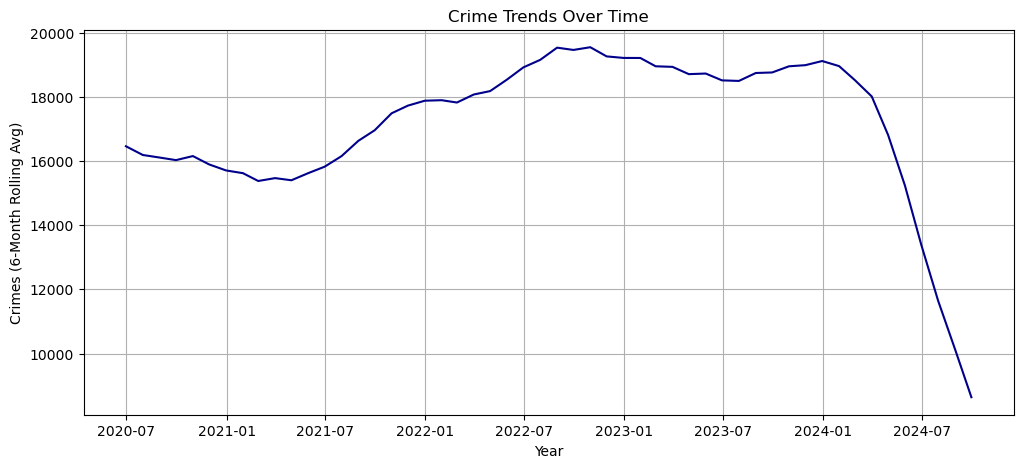

In [28]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
df['Crime Count'] = 1  
crime_trend = df.resample('M', on='DATE OCC')['Crime Count'].sum().rolling(6).mean()

plt.figure(figsize=(12, 5))
plt.plot(crime_trend, color='darkblue')
plt.xlabel('Year')
plt.ylabel('Crimes (6-Month Rolling Avg)')
plt.title('Crime Trends Over Time')
plt.grid()
plt.show()


## Model Selection and Training

In [29]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON', 'Year', 'Month', 'Hour', 'DayOfWeek', 'Crime Category',
       'Crime Count'],
      dtype='object')

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

# Optional: Use a subset of data to speed things up during testing
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]
X_test_small = X_test[:3000]
y_test_small = y_test[:3000]

# Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_small)
X_test_scaled = scaler.transform(X_test_small)

# Define faster models
models = {
    "Logistic Regression": LogisticRegression(max_iter=300, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate
for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    if name == "Naive Bayes":
        model.fit(X_train_small, y_train_small)
        y_pred = model.predict(X_test_small)
    else:
        model.fit(X_train_scaled, y_train_small)
        y_pred = model.predict(X_test_scaled)
    print(f"✅ Accuracy for {name}: {accuracy_score(y_test_small, y_pred):.4f}")



🚀 Training Logistic Regression...
✅ Accuracy for Logistic Regression: 0.2000

🚀 Training Random Forest...
✅ Accuracy for Random Forest: 0.1887

🚀 Training Naive Bayes...
✅ Accuracy for Naive Bayes: 0.0360


#### Trying to improve the Accuraccy of the Trained Models:

In [32]:
import pandas as pd

print("Number of unique target classes:", pd.Series(y).nunique())


Number of unique target classes: 138


In [39]:
import numpy as np

print("Number of unique target classes:", len(np.unique(y)))


Number of unique target classes: 138


In [40]:
import pandas as pd
pd.Series(y).value_counts().head(20)  # Top 20 most frequent classes


56     32107
61     21497
26     17966
15     17878
79     17450
13     17010
6      15426
38     14856
63     13194
28     11634
16     10504
17     10040
4       9570
40      8357
80      7240
123     5432
109     5171
85      4203
9       3650
112     3225
dtype: int64

In [41]:
top_n = 10  # You can change this to 5, 15, etc.
y_series = pd.Series(y)
top_classes = y_series.value_counts().nlargest(top_n).index
mask = y_series.isin(top_classes)

X_filtered = X[mask]
y_filtered = y_series[mask]


In [42]:
print(X_filtered.shape)
print(y_filtered.shape)


(179018, 9)
(179018,)


#### Splitting the data into Training and Testing sets

In [43]:
from sklearn.model_selection import train_test_split

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Check the shape of train/test splits
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Training set: (143214, 9), Test set: (35804, 9)


### Model Training again with increased accuracy:

#### Logistic Regression model:

Accuracy: 0.31784158194615125

Classification Report:
               precision    recall  f1-score   support

           6       0.24      0.10      0.14      3104
          13       0.09      0.08      0.08      3369
          15       0.23      0.28      0.25      3597
          26       0.24      0.52      0.32      3698
          28       0.02      0.00      0.00      2356
          38       0.06      0.00      0.00      2908
          56       0.61      1.00      0.76      6402
          61       0.19      0.34      0.24      4287
          63       0.16      0.00      0.00      2622
          79       0.08      0.02      0.03      3461

    accuracy                           0.32     35804
   macro avg       0.19      0.23      0.18     35804
weighted avg       0.23      0.32      0.25     35804



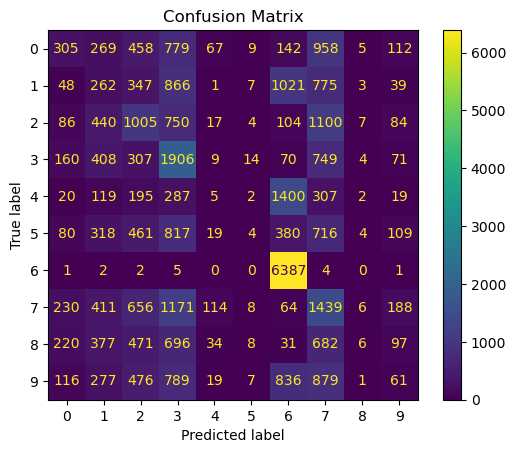

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Split the filtered dataset
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# 2. Initialize and train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
log_model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = log_model.predict(X_test)

# 4. Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


#### Random Forest model

Accuracy: 0.35658027036085355

Classification Report:
               precision    recall  f1-score   support

           6       0.24      0.22      0.23      3104
          13       0.28      0.24      0.26      3369
          15       0.31      0.36      0.33      3597
          26       0.32      0.40      0.36      3698
          28       0.19      0.06      0.09      2356
          38       0.21      0.16      0.18      2908
          56       0.64      0.90      0.75      6402
          61       0.26      0.33      0.29      4287
          63       0.20      0.18      0.19      2622
          79       0.16      0.09      0.12      3461

    accuracy                           0.36     35804
   macro avg       0.28      0.29      0.28     35804
weighted avg       0.32      0.36      0.33     35804



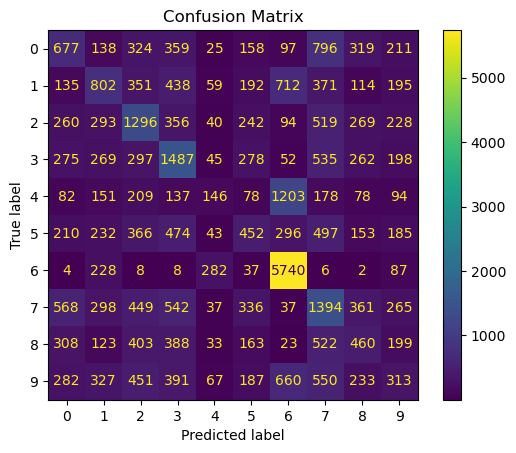

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# 2. Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 3. Predict
y_pred = rf_model.predict(X_test)

# 4. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


#### Naive Bayes model

Accuracy: 0.3308010278181209

Classification Report:
               precision    recall  f1-score   support

           6       0.23      0.13      0.16      3104
          13       0.16      0.06      0.09      3369
          15       0.23      0.42      0.30      3597
          26       0.23      0.55      0.32      3698
          28       0.04      0.01      0.01      2356
          38       0.19      0.03      0.05      2908
          56       0.61      1.00      0.76      6402
          61       0.21      0.22      0.21      4287
          63       0.18      0.11      0.14      2622
          79       0.06      0.00      0.01      3461

    accuracy                           0.33     35804
   macro avg       0.21      0.25      0.20     35804
weighted avg       0.25      0.33      0.26     35804



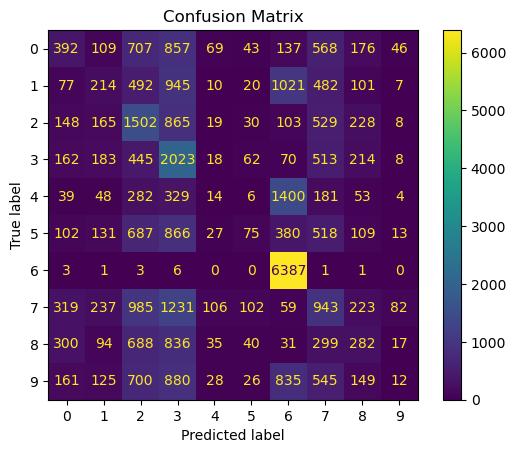

In [46]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# 2. Initialize and train the Gaussian Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 3. Predict
y_pred = nb_model.predict(X_test)

# 4. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


### Hyperparameter Tuning 

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Hyperparameters: {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 229}
Best CV Accuracy: 0.3726172022288324

Test Accuracy: 0.3813540386548989

Classification Report:
               precision    recall  f1-score   support

           6       0.28      0.18      0.22      3104
          13       0.33      0.20      0.25      3369
          15       0.31      0.43      0.36      3597
          26       0.31      0.55      0.40      3698
          28       0.43      0.01      0.02      2356
          38       0.26      0.13      0.17      2908
          56       0.63      0.97      0.76      6402
          61       0.26      0.40      0.31      4287
          63       0.23      0.16      0.19      2622
          79       0.26      0.03      0.05      3461

    accuracy                           0.38     35804
   macro avg       0.33      0.31      0.27     35804
weighte

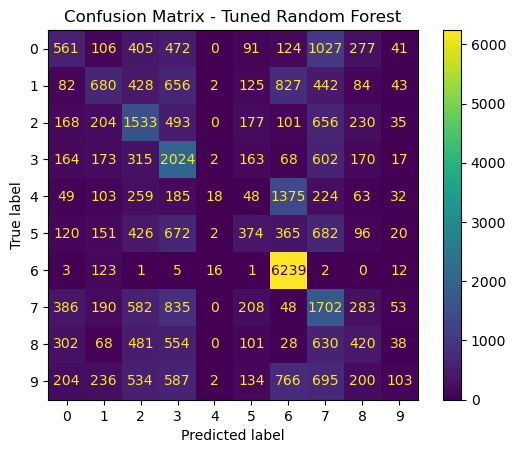

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

# Define the parameter distribution
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Randomized search setup
random_search = RandomizedSearchCV(estimator=rf,
                                   param_distributions=param_dist,
                                   n_iter=5,       # number of combinations to try
                                   cv=3,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1,
                                   scoring='accuracy')

# Fit the model
random_search.fit(X_train, y_train)

# Results
print("Best Hyperparameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

# Predict and evaluate
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()


### Error Analysis

In [50]:
import pandas as pd

# Make sure y_test is a Series to support indexing
if isinstance(y_test, np.ndarray):
    y_test_series = pd.Series(y_test, index=X_test.index)
else:
    y_test_series = y_test

# Get misclassified samples
misclassified_idx = y_test_series != y_pred
misclassified_samples = X_test[misclassified_idx]

print("Number of misclassified samples:", len(misclassified_samples))


Number of misclassified samples: 22150


In [55]:
from sklearn.metrics import classification_report

print("Classification Report for Best Model (Random Forest):")
print(classification_report(y_test, y_pred, zero_division=0))


Classification Report for Best Model (Random Forest):
              precision    recall  f1-score   support

           6       0.28      0.18      0.22      3104
          13       0.33      0.20      0.25      3369
          15       0.31      0.43      0.36      3597
          26       0.31      0.55      0.40      3698
          28       0.43      0.01      0.02      2356
          38       0.26      0.13      0.17      2908
          56       0.63      0.97      0.76      6402
          61       0.26      0.40      0.31      4287
          63       0.23      0.16      0.19      2622
          79       0.26      0.03      0.05      3461

    accuracy                           0.38     35804
   macro avg       0.33      0.31      0.27     35804
weighted avg       0.35      0.38      0.33     35804

